In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv('data/xg_model.csv')

In [3]:
df.head()

,x,y,is_goal,period,Assisted,Zone,IndividualPlay,RegularPlay,LeftFoot,RightFoot,...,Volley,FastBreak,ThrowinSetPiece,Penalty,OneOnOne,KeyPass,DirectFreekick,OwnGoal,OtherBodyPart,DirectCorner
0,80.8,51.6,False,SecondHalf,True,Center,True,True,True,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,79.3,24.2,False,SecondHalf,True,Center,True,True,NaN,True,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,80.0,59.5,False,SecondHalf,True,Center,NaN,NaN,NaN,True,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,89.8,55.6,False,SecondHalf,True,Center,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,84.9,56.2,False,SecondHalf,True,Center,NaN,True,True,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
df.shape

(8118, 25)

In [5]:
df.drop(['DirectFreekick', 'DirectCorner'], axis=1, inplace=True)

In [6]:
df.columns

Index(['x', 'y', 'is_goal', 'period', 'Assisted', 'Zone', 'IndividualPlay',
       'RegularPlay', 'LeftFoot', 'RightFoot', 'FromCorner', 'FirstTouch',
       'Head', 'BigChance', 'SetPiece', 'Volley', 'FastBreak',
       'ThrowinSetPiece', 'Penalty', 'OneOnOne', 'KeyPass', 'OwnGoal',
       'OtherBodyPart'],
      dtype='object')

In [7]:
df.OwnGoal.value_counts()

OwnGoal
True    27
Name: count, dtype: int64

In [8]:
df = df[df['OwnGoal'] != True]

In [9]:
df.drop('OwnGoal', axis=1, inplace=True)

In [10]:
df.is_goal.value_counts()

is_goal
False    7097
True      994
Name: count, dtype: int64

<Axes: xlabel='x', ylabel='y'>

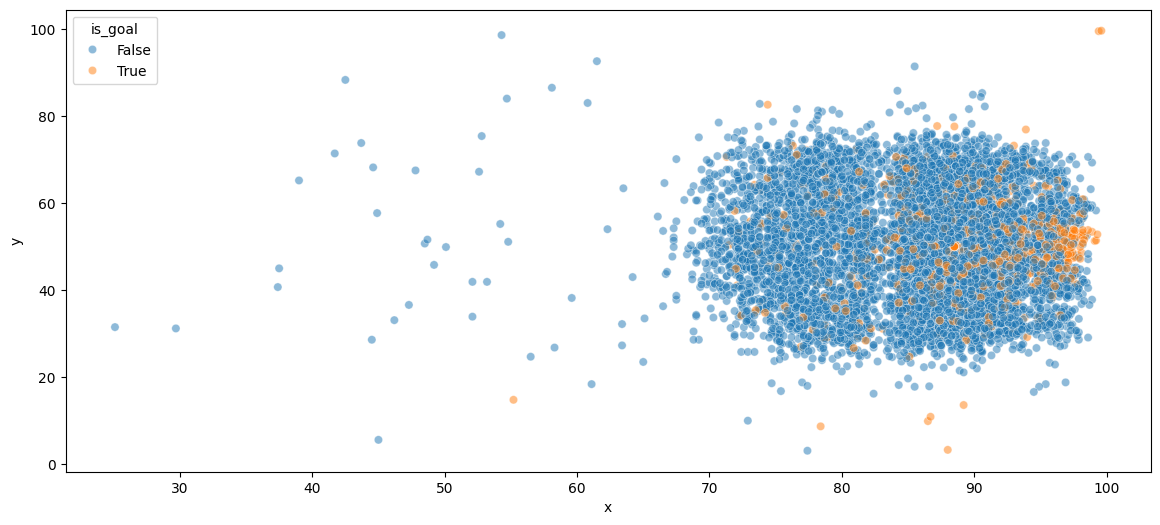

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 6))
sns.scatterplot(x='x', y='y', data=df, hue='is_goal', alpha=0.5)

In [12]:
df.isna().sum()

x                     0
y                     0
is_goal               0
period                0
Assisted           2053
Zone                  0
IndividualPlay     5289
RegularPlay        2714
LeftFoot           5307
RightFoot          4106
FromCorner         6903
FirstTouch         4166
Head               6793
BigChance          6484
SetPiece           7704
Volley             7281
FastBreak          7476
ThrowinSetPiece    7904
Penalty            7985
OneOnOne           7890
KeyPass            8033
OtherBodyPart      8067
dtype: int64

In [13]:
df.fillna(0, inplace=True)

In [14]:
df.dtypes

x                  float64
y                  float64
is_goal               bool
period              object
Assisted            object
Zone                object
IndividualPlay      object
RegularPlay         object
LeftFoot            object
RightFoot           object
FromCorner          object
FirstTouch          object
Head                object
BigChance           object
SetPiece            object
Volley              object
FastBreak           object
ThrowinSetPiece     object
Penalty             object
OneOnOne            object
KeyPass             object
OtherBodyPart       object
dtype: object

In [15]:
df.astype({
    'x': float,
    'y': float,
    'is_goal': bool,
    'period': str,
    'Assisted': bool,
    'Zone': str,
    'IndividualPlay': bool,
    'RegularPlay': bool,
    'LeftFoot': bool,
    'RightFoot': bool,
    'FromCorner': bool,
    'FirstTouch': bool,
    'Head': bool,
    'BigChance': bool,
    'SetPiece': bool,
    'Volley': bool,
    'FastBreak': bool,
    'ThrowinSetPiece': bool,
    'Penalty': bool,
    'OneOnOne': bool,
    'KeyPass': bool,
    'OtherBodyPart': bool
})

,x,y,is_goal,period,Assisted,Zone,IndividualPlay,RegularPlay,LeftFoot,RightFoot,...,Head,BigChance,SetPiece,Volley,FastBreak,ThrowinSetPiece,Penalty,OneOnOne,KeyPass,OtherBodyPart
0,80.8,51.6,False,SecondHalf,True,Center,True,True,True,False,...,False,False,False,False,False,False,False,False,False,False
1,79.3,24.2,False,SecondHalf,True,Center,True,True,False,True,...,False,False,False,False,False,False,False,False,False,False
2,80.0,59.5,False,SecondHalf,True,Center,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
3,89.8,55.6,False,SecondHalf,True,Center,False,False,False,False,...,True,False,False,False,False,False,False,False,False,False
4,84.9,56.2,False,SecondHalf,True,Center,False,True,True,False,...,False,True,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8113,86.4,34.0,False,FirstHalf,False,Center,False,True,False,True,...,False,True,False,False,False,False,False,False,False,False
8114,92.4,51.0,False,FirstHalf,True,Center,False,True,False,False,...,True,True,False,False,False,False,False,False,False,False
8115,88.6,37.8,False,FirstHalf,True,Center,False,True,False,True,...,False,False,False,True,False,False,False,False,False,False
8116,89.6,48.1,False,FirstHalf,True,Center,False,True,False,False,...,True,True,False,False,False,False,False,False,False,False


In [16]:
df['ShotDistance'] = np.sqrt((df['x'] - 100)**2 + (df['y'] - 50)**2)

In [17]:
#CategoricalEnconding
df = pd.get_dummies(df, columns=['period', 'Zone'])

In [18]:
df.columns

Index(['x', 'y', 'is_goal', 'Assisted', 'IndividualPlay', 'RegularPlay',
       'LeftFoot', 'RightFoot', 'FromCorner', 'FirstTouch', 'Head',
       'BigChance', 'SetPiece', 'Volley', 'FastBreak', 'ThrowinSetPiece',
       'Penalty', 'OneOnOne', 'KeyPass', 'OtherBodyPart', 'ShotDistance',
       'period_FirstHalf', 'period_SecondHalf', 'Zone_Back', 'Zone_Center',
       'Zone_Left', 'Zone_Right'],
      dtype='object')

In [19]:
X = df.drop('is_goal', axis=1)
y = df['is_goal']

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss, roc_auc_score, brier_score_loss

In [21]:
X_test, X_train, y_test, y_train = train_test_split(X, y, test_size=0.2, random_state=42)

In [22]:
model = LogisticRegression(max_iter=1000)

In [23]:
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [24]:
y_pred_proba = model.predict_proba(X_test)[:,1]

In [25]:
final_df = X_test.copy()
final_df['goal_probability'] = y_pred_proba

In [26]:
final_df.sort_values(by='goal_probability', ascending=False).head()

,x,y,Assisted,IndividualPlay,RegularPlay,LeftFoot,RightFoot,FromCorner,FirstTouch,Head,...,KeyPass,OtherBodyPart,ShotDistance,period_FirstHalf,period_SecondHalf,Zone_Back,Zone_Center,Zone_Left,Zone_Right,goal_probability
504,88.5,50.0,0,0,0,True,0,0,0,0,...,0,0,11.5,True,False,False,True,False,False,0.780373
927,88.5,50.0,0,0,0,True,0,0,0,0,...,0,0,11.5,True,False,False,True,False,False,0.780373
6495,88.5,50.0,0,0,0,True,0,0,0,0,...,0,0,11.5,True,False,False,True,False,False,0.780373
7298,88.5,50.0,0,0,0,True,0,0,0,0,...,0,0,11.5,True,False,False,True,False,False,0.780373
498,88.5,50.0,0,0,0,True,0,0,0,0,...,0,0,11.5,True,False,False,True,False,False,0.780373


In [27]:
log_loss(y_test, y_pred_proba)

0.29385217591060275

In [28]:
roc_auc_score(y_test, y_pred_proba)

0.794619425147507

In [29]:
brier_score_loss(y_test, y_pred_proba)

0.08476934068436731

In [30]:
from mplsoccer import Pitch
pitch = Pitch(pitch_type='opta')

In [31]:
from matplotlib.colors import LinearSegmentedColormap
colors = ['red', 'yellow', 'green']

cmap = LinearSegmentedColormap.from_list('xG Colors', colors)

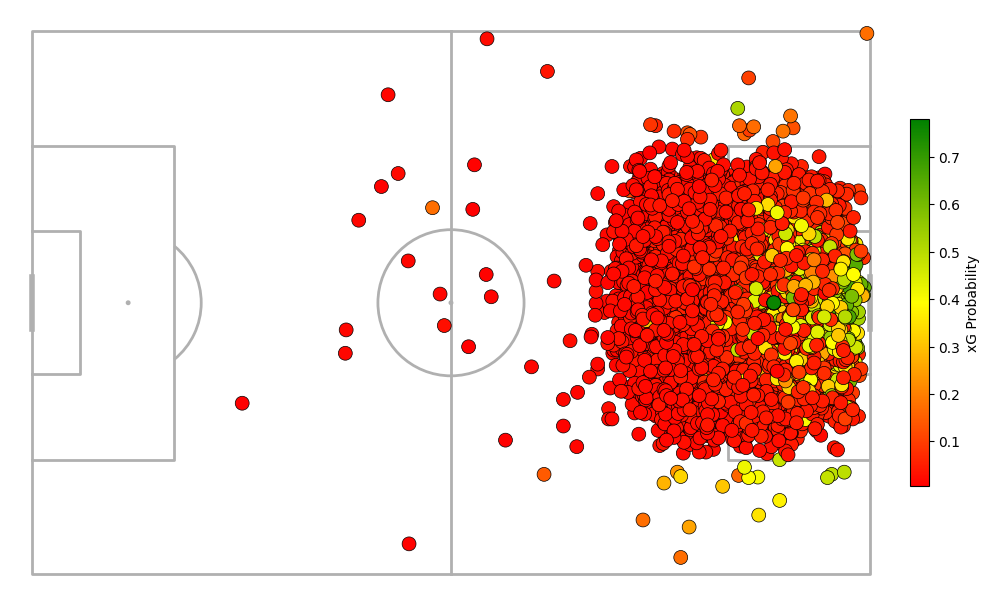

In [32]:
fig, ax = pitch.draw(figsize=(10, 8))
sc = pitch.scatter(final_df['x'], final_df['y'], c=final_df['goal_probability'], cmap=cmap, edgecolors='black', linewidth=.5, s=100, ax=ax)
cbar = plt.colorbar(sc, ax=ax, orientation='vertical', fraction=.02, pad=.02)
cbar.set_label('xG Probability')